In [1]:
import numpy as np
import pandas as pd

from IPython.core.display import display, HTML
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import EasyEnsembleClassifier

import seaborn as sns
from importlib import reload
import matplotlib.pyplot as plt
import matplotlib
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [2]:
# Import and display the dataset

df=pd.read_csv("/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv")
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [3]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
# Checking for null values and duplicates

print(df.isnull().sum())
print("")
print(f"Duplicated rows :", df.duplicated().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicated rows : 0


Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


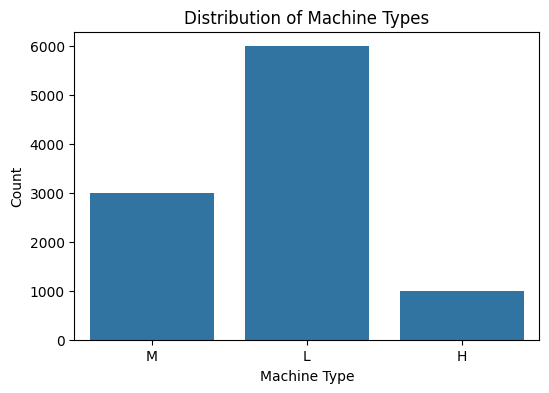

In [5]:
# Count of each type and statistics

print(df['Type'].value_counts())


plt.figure(figsize=(6,4))
sns.countplot(x='Type', data=df)
plt.title('Distribution of Machine Types')
plt.xlabel('Machine Type')
plt.ylabel('Count')
plt.show()

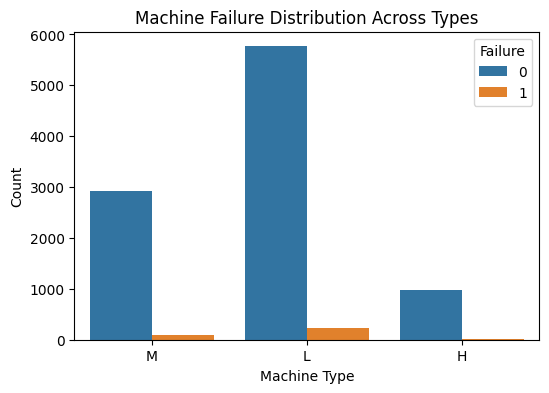

In [6]:
# Visualize how failures are spread across types

plt.figure(figsize=(6,4))
sns.countplot(x='Type', hue='Machine failure', data=df)
plt.title('Machine Failure Distribution Across Types')
plt.xlabel('Machine Type')
plt.ylabel('Count')
plt.legend(title='Failure')
plt.show()

In [7]:
# Turn all columns into float to make processing later easier

for column in df.columns:
    try:
        df[column]=df[column].astype(float)
    except:
        pass

print("Done")

Done


In [8]:
# Show the numeric features
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


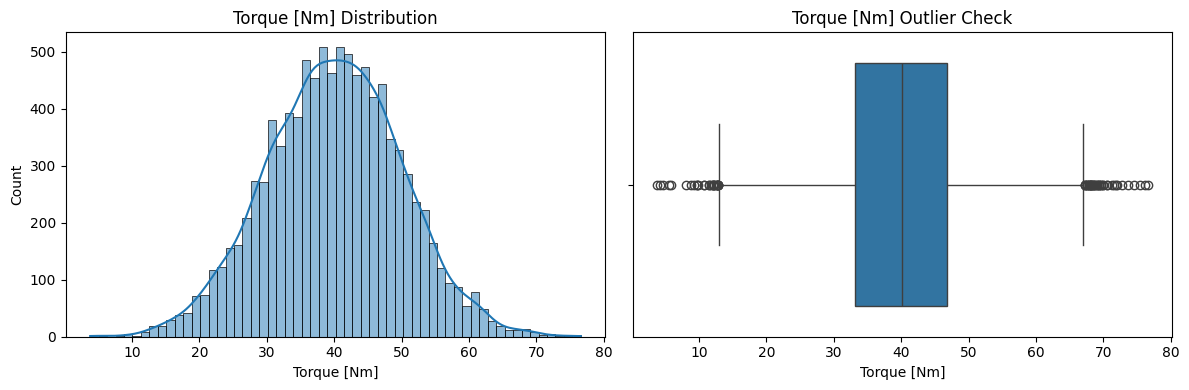

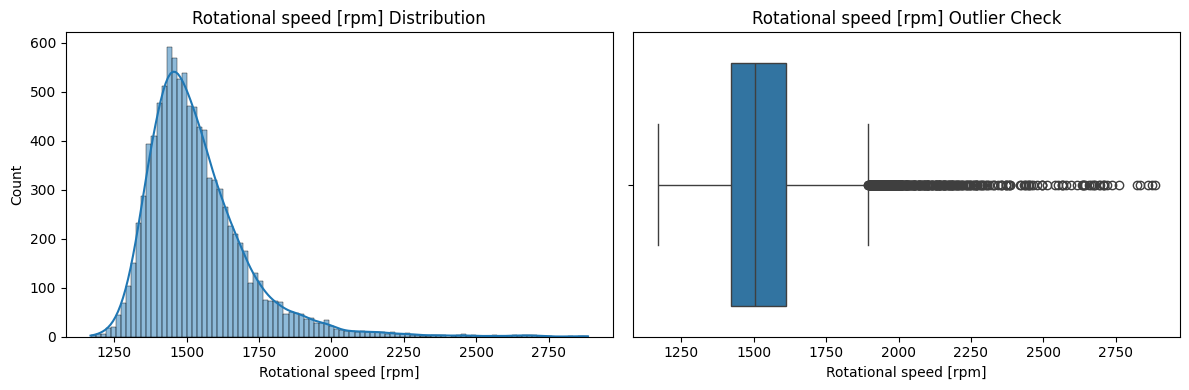

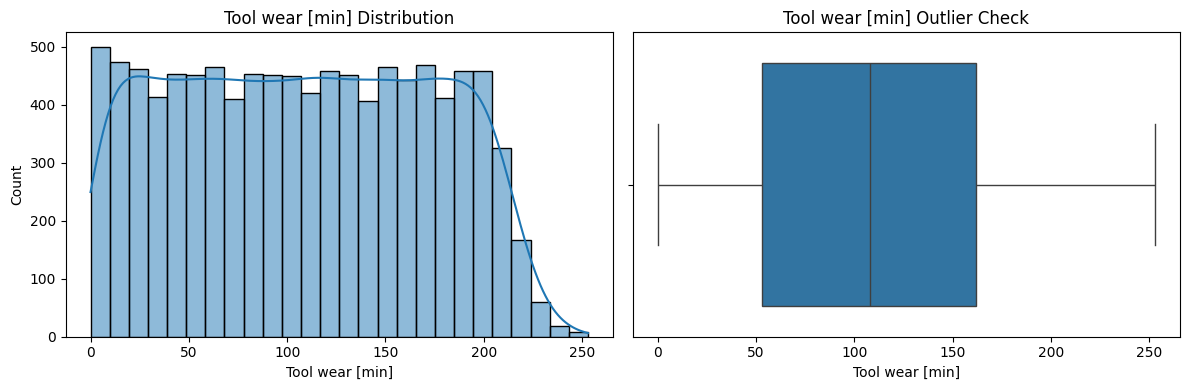

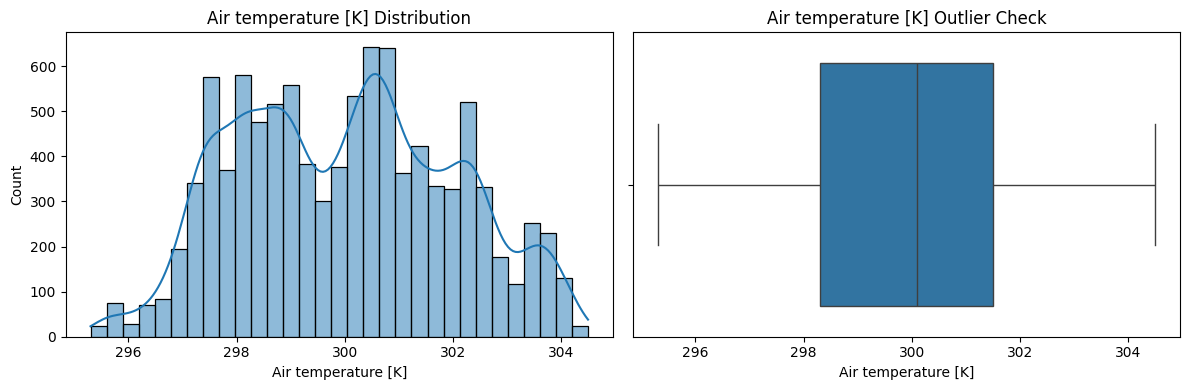

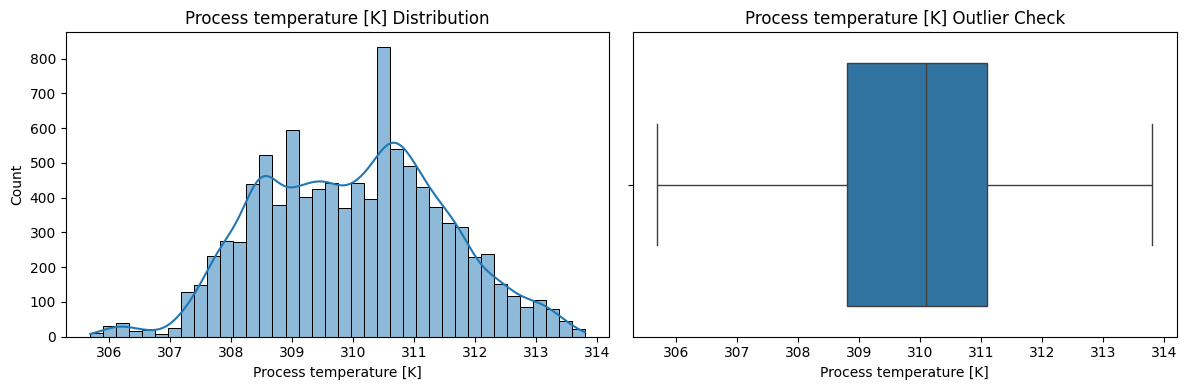

In [9]:
# Plot Feature Distributions to Observe Patterns or Anomalies

cols = ['Torque [Nm]', 'Rotational speed [rpm]','Tool wear [min]','Air temperature [K]','Process temperature [K]']

for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4)) 

    # Histogram with KDE
    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} Distribution")

    # Boxplot
    sns.boxplot(data=df, x=col, ax=axes[1])
    axes[1].set_title(f"{col} Outlier Check")

    plt.tight_layout()
    plt.show()

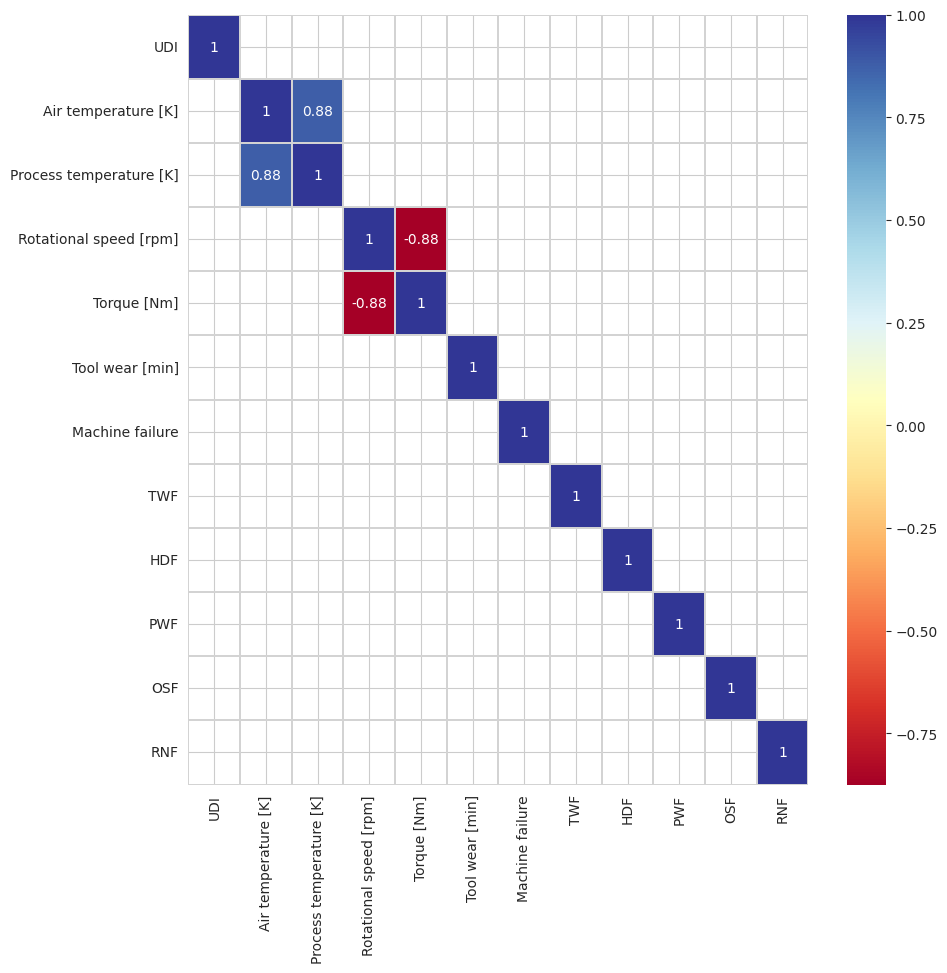

In [10]:
# Correlation

plt.figure(figsize=(10,10))
threshold = 0.80
sns.set_style("whitegrid", {"axes.facecolor": ".0"})
df_cluster2 = df_numeric.corr()
mask = df_cluster2.where((abs(df_cluster2) >= threshold)).isna()
plot_kws={"s": 1}
sns.heatmap(df_cluster2,
            cmap='RdYlBu',
            annot=True,
            mask=mask,
            linewidths=0.2, 
            linecolor='lightgrey').set_facecolor('white')

In [11]:
# Drop the indices and the failure modes

df.drop(['UDI','Product ID','TWF','HDF','PWF','OSF','RNF'],axis=1,inplace=True)

In [12]:
# The remaining features

list(df)

['Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure']

In [13]:
# Visualize data imbalance

df_group = df.groupby(['Machine failure'])
df_group.count()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,,
0.0,9661,9661,9661,9661,9661,9661
1.0,339,339,339,339,339,339


In [14]:
# Logical mapping to keep the order Low Medium High
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

# Definition of X and y keeping consistent casing
y = df.pop("Machine failure")
X = df

In [15]:
# Performing train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Scaling numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

In [17]:
# Importing machine learning models

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV,SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier,BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [18]:
# Define models with class balancing where applicable
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Logistic Regression CV': LogisticRegressionCV(class_weight='balanced', random_state=42),
    'SGD': SGDClassifier(class_weight='balanced', loss='log_loss', random_state=42), 
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'EasyEnsemble': EasyEnsembleClassifier(n_estimators=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Bagging': BaggingClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Support Vector Machine': SVC(class_weight='balanced', probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

In [19]:
# Creating a function to fit models on our dataset and check which model gives highest accuracy

def compare_models(X_train,X_test,Y_train,Y_test):
    result=[]
    for name, model in models.items():
        model.fit(X_train,Y_train)
        y_pred=model.predict(X_test)
        acc=accuracy_score(Y_test,y_pred)
        result.append((name,acc))
    # Sort models by accuracy
    result.sort(key=lambda x: x[1], reverse=True)
    return result

In [20]:
# Launch evaluation with the correct parameters
results = compare_models(X_train_scaled, X_test_scaled, y_train, y_test)
    
print("Model Performance:")
for name, acc in results:
    print(f"{name}: {acc:.6f}")

Model Performance:
Bagging: 0.984500
Gradient Boosting: 0.983500
Random Forest: 0.982000
K-Nearest Neighbors: 0.979000
Decision Tree: 0.977500
AdaBoost: 0.976000
Support Vector Machine: 0.915000
SGD: 0.893500
EasyEnsemble: 0.869500
Logistic Regression CV: 0.818000
Logistic Regression: 0.817500


In [21]:
# Without SMOTE
RF=RandomForestClassifier(class_weight='balanced', random_state=42)

RF.fit(X_train_scaled, y_train)
y_pred=RF.predict(X_test_scaled)
acc=accuracy_score(y_test, y_pred)

print(f"Accuracy RF :", acc)

Accuracy RF : 0.982


In [22]:
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_auc_score, 
    RocCurveDisplay, 
    precision_recall_curve, 
    PrecisionRecallDisplay
)

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Classification Report
    print(f"{model_name} Classification Report \n\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    # ROC Curve
    roc_auc = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"{model_name} ROC Curve AUC = {roc_auc:.2f}")
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    PrecisionRecallDisplay(precision=precision, recall=recall).plot()
    plt.title(f"{model_name} Precision Recall Curve")
    plt.show()

Random Forest Classification Report 


              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      1939
         1.0       0.88      0.48      0.62        61

    accuracy                           0.98      2000
   macro avg       0.93      0.74      0.80      2000
weighted avg       0.98      0.98      0.98      2000



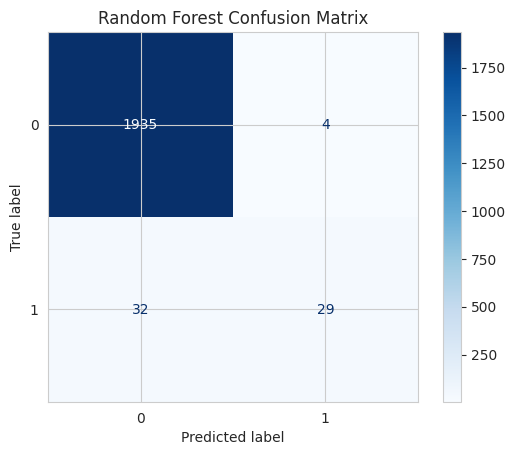

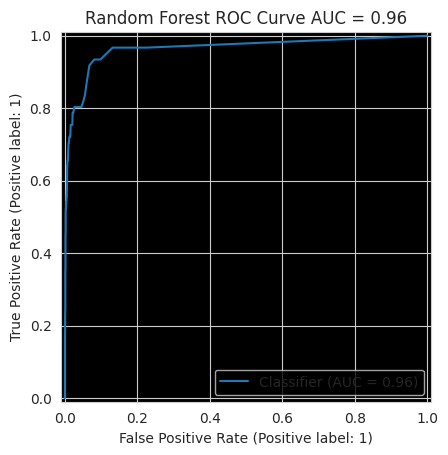

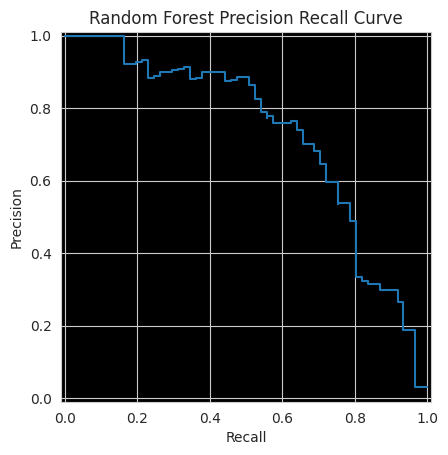

In [23]:
evaluate_model(RF, X_test_scaled, y_test, model_name="Random Forest")

In [24]:
# 1. Retrieve raw probabilities instead of 0 and 1
y_prob = RF.predict_proba(X_test_scaled)[:, 1]

# 2. Create a function to easily test multiple thresholds
def tester_seuil(y_test, y_prob, seuil):
    # If probability is greater than the threshold, set to 1, otherwise 0
    y_pred_perso = (y_prob >= seuil).astype(int)
    
    cm = confusion_matrix(y_test, y_pred_perso)
    
    vrais_positifs = cm[1, 1]
    faux_negatifs = cm[1, 0] # Missed failures
    faux_positifs = cm[0, 1] # False alarms
    vrais_negatifs = cm[0, 0]
    
    print(f"Decision threshold: {seuil} {seuil*100} percent")
    print(f"Detected failures True Positives : {vrais_positifs} / 61")
    print(f"Missed failures False Negatives  : {faux_negatifs} / 61")
    print(f"False alarms False Positives  : {faux_positifs}")
    print("")

# 3. Test model evolution with different thresholds
seuils_a_tester = [0.2, 0.3, 0.4, 0.5]

for s in seuils_a_tester:
    tester_seuil(y_test, y_prob, s)

Decision threshold: 0.2 20.0 percent
Detected failures True Positives : 46 / 61
Missed failures False Negatives  : 15 / 61
False alarms False Positives  : 36

Decision threshold: 0.3 30.0 percent
Detected failures True Positives : 43 / 61
Missed failures False Negatives  : 18 / 61
False alarms False Positives  : 20

Decision threshold: 0.4 40.0 percent
Detected failures True Positives : 35 / 61
Missed failures False Negatives  : 26 / 61
False alarms False Positives  : 11

Decision threshold: 0.5 50.0 percent
Detected failures True Positives : 29 / 61
Missed failures False Negatives  : 32 / 61
False alarms False Positives  : 4



Final predictions successfully generated with a threshold of 30.0 percent


Classification Report Threshold = 0.3 

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1939
         1.0       0.68      0.70      0.69        61

    accuracy                           0.98      2000
   macro avg       0.84      0.85      0.84      2000
weighted avg       0.98      0.98      0.98      2000



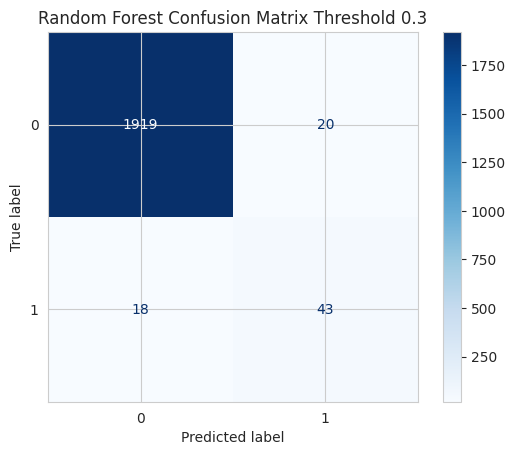

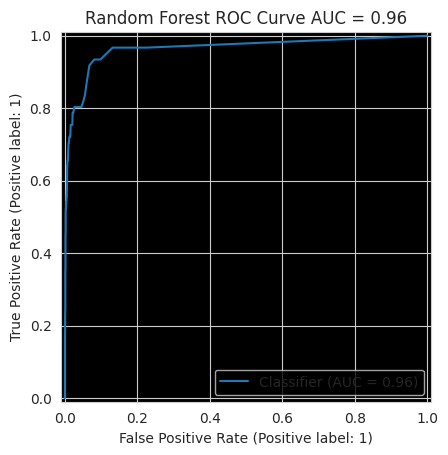

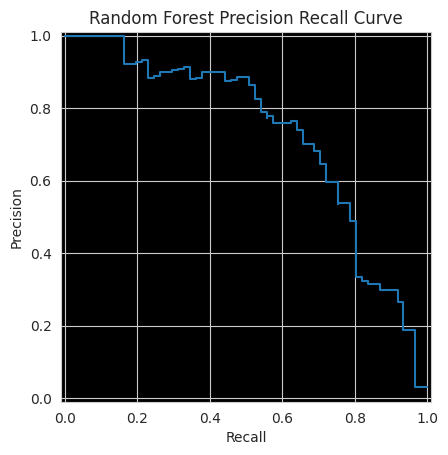

In [25]:
# APPLICATION OF THE FINAL THRESHOLD FOR PRODUCTION
SEUIL_OPTIMAL = 0.3

# 1. Retrieve probabilities
y_prob_final = RF.predict_proba(X_test_scaled)[:, 1]

# 2. Generate strict final predictions 0 or 1 based on the threshold
y_pred_final = (y_prob_final >= SEUIL_OPTIMAL).astype(int)

# 3. Create a results dataframe
resultats_df = pd.DataFrame({
    'Probabilite_Panne': y_prob_final,
    'Prediction_Finale': y_pred_final,
    'Verite_Terrain': y_test.values
})

print(f"Final predictions successfully generated with a threshold of {SEUIL_OPTIMAL*100} percent\n")
print("")

# DISPLAY VISUAL AND METRIC RESULTS

# Classification Report
print(f"Classification Report Threshold = {SEUIL_OPTIMAL} \n")
print(classification_report(y_test, y_pred_final))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f"Random Forest Confusion Matrix Threshold {SEUIL_OPTIMAL}")
plt.show()

# ROC Curve
# The ROC curve does not change with the threshold it evaluates global probabilities
roc_auc = roc_auc_score(y_test, y_prob_final)
RocCurveDisplay.from_predictions(y_test, y_prob_final)
plt.title(f"Random Forest ROC Curve AUC = {roc_auc:.2f}")
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_final)
PrecisionRecallDisplay(precision=precision, recall=recall).plot()
plt.title(f"Random Forest Precision Recall Curve")
plt.show()

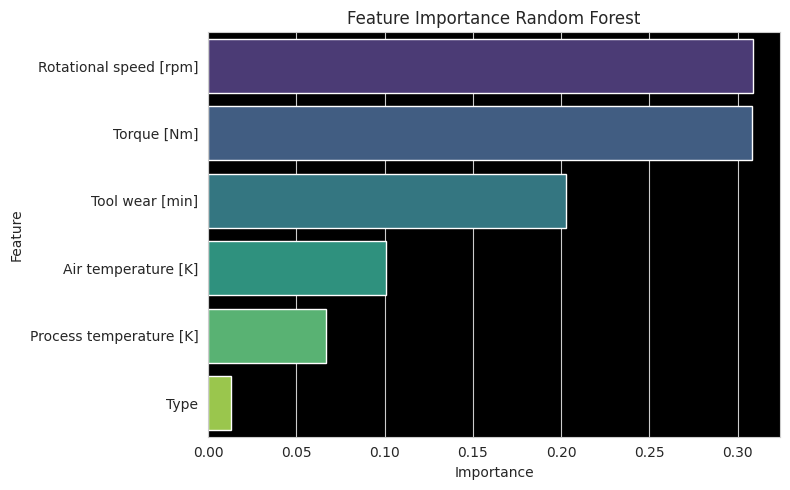

In [26]:
importances = RF.feature_importances_
feature_names = X.columns

# Create a DataFrame
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance Random Forest')
plt.tight_layout()
plt.show()

In [27]:
import joblib

# Sauvegarde du modèle final et du scaler
joblib.dump(RF, 'random_forest_model.joblib')
joblib.dump(scaler, 'standard_scaler.joblib')

print("Modèle et scaler sauvegardés avec succès !")

Modèle et scaler sauvegardés avec succès !
